Using instance segmentation to separate pets

In [ ]:
import torch
import torchvision
import torchvision.transforms as T
from torchvision.transforms import InterpolationMode
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from torchvision.ops import nms
from PIL import Image
import matplotlib.colors as mcolors
from scipy.ndimage import label

In [ ]:
data_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])
mask_transform = T.Compose([
    T.Resize((256, 256), interpolation=InterpolationMode.NEAREST),
    T.ToTensor()
])

dataset = torchvision.datasets.OxfordIIITPet(
    root="./data",
    target_types="segmentation",
    download=True,
    transform=data_transform,
    target_transform=mask_transform
)
#Split into train/test
#train_size  = int(0.8 * len(dataset))
#test_size   = len(dataset) - train_size
#train_dataset, test_dataset = torch.utils.data.random_split(
    #dataset, [train_size, test_size],
    #generator=torch.Generator().manual_seed(42)   # reproducible split
#)


# Use only few images as my computer got limited computing power
subset_indices = list(range(50))
small_dataset  = torch.utils.data.Subset(dataset, subset_indices)

train_size = 40  # 80% of 200
test_size  = 10   # 20% of 200

train_dataset, test_dataset = torch.utils.data.random_split(
    small_dataset, [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
img, mask = train_dataset[0]
print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 792M/792M [00:31<00:00, 25.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.5MB/s]


Train: 40 | Test: 10
40
10


In [ ]:
train_loader = DataLoader(
    train_dataset, batch_size=4, shuffle=True,
    collate_fn=lambda x: tuple(zip(*x))
)

In [ ]:
images, targets = next(iter(train_loader))
print(f"Images in one batch: {len(images)}")
print(f"Each image shape: {images[0].shape}")

Images in one batch: 4
Each image shape: torch.Size([3, 256, 256])


In [ ]:
def get_model(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")

    # Freeze backbone (from v1)
    for param in model.backbone.parameters():
        param.requires_grad = False
    # Freeze the RPN so it stops proposing hundreds of
    # candidate regions that the undertrained classifier cannot reject.
    for param in model.rpn.parameters():
        param.requires_grad = False

    # Drastically cut the number of region proposals at inference.
    # Default values (1000 / 1000 / 100) are tuned for COCO's 80 classes —
    # way too many for a binary pet/background task.
    model.rpn.pre_nms_top_n_test        = 1000
    # default: 1000
    model.rpn.post_nms_top_n_test       = 1000
    # default: 1000
    model.roi_heads.detections_per_img  = 50
    # default: 100
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes)
    return model

In [ ]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

model = get_model(num_classes=2)
model.to(device)
# collect trainable params as a plain list — filter() returns a
# one-shot generator that gets exhausted after the first optimizer step,
# causing the loop to silently stall from epoch 2 onward.
trainable_params = [p for p in model.parameters() if p.requires_grad]
print(f"Trainable parameter groups: {len(trainable_params)}")

optimizer = torch.optim.Adam(trainable_params, lr=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)


def prepare_targets(images_list, targets, device):
    """
    Accepts both images and targets together and filters them as
    matched pairs. Generates one box/mask per pet instance by
    looping over connected components in the mask.
    """
    valid_images  = []
    valid_targets = []

    for img, t in zip(images_list, targets):
        # After ToTensor(), Oxford Pet mask values are 1/255≈0.004, 2/255≈0.008, 3/255≈0.012
        # This isolates pixel value == 1 (pet foreground) correctly
        binary_mask = (t < (2 / 255.0)).float() * (t > (0.5 / 255.0)).float()

        # Convert mask to numpy to find connected components
        mask_np = binary_mask[0].cpu().numpy()
        labeled_mask, num_instances = label(mask_np)

        if num_instances == 0:
            continue

        boxes = []
        masks = []
        labels = []

        # Loop over each connected component to create individual instance targets
        for i in range(1, num_instances + 1):
            # Isolate the current connected component (instance)
            instance_mask = (labeled_mask == i)

            pos = np.where(instance_mask)
            if pos[0].size == 0:
                continue

            # Calculate bounding box coordinates for this instance
            ymin, ymax = np.min(pos[0]), np.max(pos[0])
            xmin, xmax = np.min(pos[1]), np.max(pos[1])

            # Ignore invalid bounding boxes
            if xmin == xmax or ymin == ymax:
                continue

            boxes.append([xmin, ymin, xmax, ymax])
            masks.append(instance_mask)
            labels.append(1)

        # If no valid boxes were found for this image, skip it
        if len(boxes) == 0:
            continue

        valid_images.append(img)
        valid_targets.append({
            "boxes":  torch.tensor(boxes, dtype=torch.float32).to(device),
            "labels": torch.tensor(labels, dtype=torch.int64).to(device),
            "masks":  torch.tensor(np.array(masks), dtype=torch.float32).to(device)  # Yields shape [N, H, W]
        })

    return valid_images, valid_targets

model.train()
NUM_EPOCHS = 2

for epoch in range(NUM_EPOCHS):
    epoch_loss = 0.0
    skipped    = 0
    batches    = 0

    for i, (images, targets) in enumerate(train_loader):
        images = [img.to(device) for img in images]

        valid_images, valid_targets = prepare_targets(images, targets, device)

        if len(valid_targets) == 0:
            skipped += 1
            continue

        loss_dict = model(valid_images, valid_targets)
        losses    = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()
        batches    += 1
        # Print every 10 batches so you can confirm the loop is running
        if i % 10 == 0:
            print(f"  Epoch {epoch+1} | Batch {i} | Loss: {losses.item():.4f}", flush=True)
    avg_loss = epoch_loss / batches if batches > 0 else float('nan')
    if batches > 0:
        scheduler.step()
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] — Avg Loss: {avg_loss:.4f} | Skipped: {skipped}", flush=True)

Using device: cpu
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:01<00:00, 90.7MB/s]


Trainable parameter groups: 20
  Epoch 1 | Batch 0 | Loss: 4.8011
Epoch [1/2] — Avg Loss: 1.1621 | Skipped: 0
  Epoch 2 | Batch 0 | Loss: 0.4547
Epoch [2/2] — Avg Loss: 0.4375 | Skipped: 0


Detected 2 pet(s) with score > 0.5


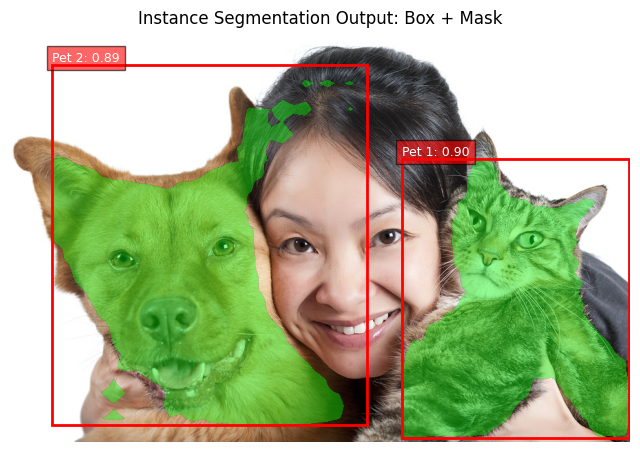

In [ ]:
img = Image.open("catdoghuman.jpg").convert("RGB")
img_tensor = T.ToTensor()(img).to(device)

SCORE_THRESHOLD   = 0.5   # was 0.75
NMS_IOU_THRESHOLD = 0.15   # was 0.30 — more aggressive overlap suppression
model.eval()
with torch.no_grad():
    # Use test_dataset so inference is on an image the model never trained on
    test_img, _ = test_dataset[1]   # was: dataset[0]
    #prediction = model([test_img.to(device)])
    prediction = model([img_tensor])

boxes  = prediction[0]['boxes']
scores = prediction[0]['scores']
masks  = prediction[0]['masks']

# filter by confidence
keep   = scores > SCORE_THRESHOLD
boxes  = boxes[keep]
scores = scores[keep]
masks  = masks[keep]

# explicit NMS
if len(boxes) > 0:
    keep_nms = nms(boxes, scores, iou_threshold=NMS_IOU_THRESHOLD)
    boxes    = boxes[keep_nms].cpu().numpy()
    scores   = scores[keep_nms].cpu().numpy()
    masks    = masks[keep_nms].cpu().numpy()
else:
    boxes  = boxes.cpu().numpy()
    scores = scores.cpu().numpy()
    masks  = masks.cpu().numpy()

#img_display = test_img.permute(1, 2, 0).cpu().numpy()
img_display = img_tensor.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.imshow(img_display)
ax = plt.gca()

if len(boxes) == 0:
    print("No confident detections. Try more epochs or lower SCORE_THRESHOLD.")
else:
    for i, (box, score, mask) in enumerate(zip(boxes, scores, masks)):
        rect = plt.Rectangle(
            (box[0], box[1]), box[2] - box[0], box[3] - box[1],
            fill=False, color='red', linewidth=2
        )
        ax.add_patch(rect)
        plt.text(
            box[0], box[1] - 5,
            f'Pet {i+1}: {score:.2f}',
            color='white', fontsize=9,
            bbox=dict(facecolor='red', alpha=0.6)
        )

        mask_display = mask[0] > 0.5
        colored_mask = np.zeros((*mask_display.shape, 4))
        colored_mask[mask_display] = [0, 1, 0, 0.4]
        ax.imshow(colored_mask)

    print(f"Detected {len(boxes)} pet(s) with score > {SCORE_THRESHOLD}")

plt.title("Instance Segmentation Output: Box + Mask")
plt.axis('off')
plt.show()